# 07 — Human-in-the-loop：`interrupt()` 讓圖暫停，等人來決定

**這份要學什麼**
- `interrupt()` 讓圖在某個節點暫停，`Command(resume=...)` 讓它從原地繼續
- 為什麼這招一定要搭配 checkpointer 才能運作

> 不需要 API key。這個機制跟 LLM 完全無關——`interrupt()` 是 LangGraph 執行引擎本身的能力，
> 重點是它怎麼跟 `06` 教的 Checkpointer 搭配運作。

很多實務場景（送出 email 前、執行有風險的操作前、AI 產生的內容要人審核）都需要「暫停，
等人看過再決定要不要繼續」。

想像銀行審核流程：櫃檯人員（agent）辦到一半，發現金額太大，不能自己批准——只好按下
「暫停鍵」，叫主管來簽名。主管簽完（人類輸入），櫃檯才能繼續往下辦。`interrupt()` 就是
那個「暫停鍵」：

```
圖開始執行
   │
   ▼
跑到呼叫 interrupt(payload) 的那個 node
   │
   ▼
暫停！把 payload 丟給呼叫端（像是把單子遞給主管看）
   │
   ▼
  ...等待人類輸入...
   │
   ▼
呼叫端帶著 Command(resume=人類的決定) 再呼叫一次
   │
   ▼
繼續往下執行，resume 的值就是 interrupt() 那行「看起來」拿到的回傳值
```

**這一切都得靠 Checkpointer 才能運作**——沒有存檔系統，圖不知道自己暫停在哪一步、下次要
從哪裡接著跑。這也是為什麼 06 要先教 Checkpointer，才輪到這章。

## 這段程式碼在做什麼

- `DraftState`：存草稿內容 `draft` 跟版本號 `revision`
- `write_draft`：每跑一次版本號 +1，產生新的一版草稿
- `human_review`：呼叫 `interrupt(...)`，把「草稿內容 + 要問的問題」丟出去，暫停等人類回答
  - 人類回 `"approve"` → 回傳 `Command(goto=END)`，結束
  - 人類回其他值（這裡示範 `"reject"`）→ 回傳 `Command(goto="write_draft")`，打回重寫，
    形成一個迴圈
- `Command(goto=...)`：node 自己決定「下一步要跳去哪個 node」的寫法，效果類似 conditional
  edge，只是寫在 node 內部而不是另外接一條邊

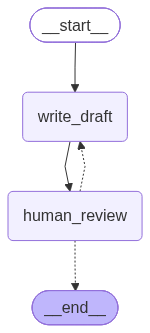

In [1]:
import sys
from typing import Literal, TypedDict

sys.path.insert(0, ".")
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

from _graph_viz import show_graph


class DraftState(TypedDict):
    draft: str
    revision: int


def write_draft(state: DraftState) -> dict:
    revision = state.get("revision", 0) + 1
    return {"draft": f"這是第 {revision} 版草稿", "revision": revision}


def human_review(state: DraftState) -> Command[Literal["write_draft", "__end__"]]:
    decision = interrupt({"draft": state["draft"], "ask": "核准嗎？('approve' / 'reject')"})
    if decision == "approve":
        return Command(goto=END)
    return Command(goto="write_draft")  # 打回重寫，形成迴圈


builder = StateGraph(DraftState)
builder.add_node("write_draft", write_draft)
builder.add_node("human_review", human_review)
builder.add_edge(START, "write_draft")
builder.add_edge("write_draft", "human_review")

graph = builder.compile(checkpointer=InMemorySaver())
show_graph(graph)
config = {"configurable": {"thread_id": "review-1"}}

## 第一次呼叫：跑到 `interrupt()` 就停下來

回傳結果裡的 `__interrupt__` 就是 `interrupt()` 丟出來的 payload——代表「圖正在問你問題，
等你回答」。`get_state(config).next` 顯示接下來排隊要跑的 node 是 `human_review`，代表圖
真的停在那裡，還沒往下走。

In [2]:
state = graph.invoke({"draft": "", "revision": 0}, config)
print(state["__interrupt__"][0].value)
print("下一個要跑的節點:", graph.get_state(config).next)

{'draft': '這是第 1 版草稿', 'ask': "核准嗎？('approve' / 'reject')"}
下一個要跑的節點: ('human_review',)


## 用 `Command(resume=...)` 回答，讓圖接著跑下去

模擬「人工駁回」：傳入 `Command(resume="reject")`。對寫程式的人來說，效果就像
`interrupt()` 那一行「收到」了 `"reject"` 這個回傳值，`human_review` 依照這個值把圖導回
`write_draft` 重寫一版，新版本又會停在 `human_review` 等下一次審核。

In [3]:
state = graph.invoke(Command(resume="reject"), config)
print(state["__interrupt__"][0].value)  # 草稿版本變成 v2，因為被打回重寫過一次

{'draft': '這是第 2 版草稿', 'ask': "核准嗎？('approve' / 'reject')"}


第二次模擬「人工核准」：傳入 `Command(resume="approve")`，圖直接走到 `END`，沒有新的
`interrupt`——代表這局審核結束了。`revision` 停在 2，因為核准後直接結束，沒有再跑一次
`write_draft`。

In [4]:
final_state = graph.invoke(Command(resume="approve"), config)
print(final_state)  # 沒有 __interrupt__ key，代表圖已經跑到底

{'draft': '這是第 2 版草稿', 'revision': 2}


## 這在真實系統裡怎麼串起來
在網頁 / API 場景裡不會用 `for` loop 連續呼叫，而是：
1. 使用者觸發一個 request，圖跑到 `interrupt()` 就回傳給前端（`__interrupt__` 內容拿去畫審核 UI）
2. 前端存著 `thread_id`，等使用者按下「核准 / 打回」
3. 後端收到動作後，用同一個 `thread_id` 呼叫 `graph.invoke(Command(resume=使用者的決定), config)`

中間即使程式重啟也沒關係，只要 checkpointer 是持久化的（見 `10_langgraph_persistence_
deploy.ipynb`），狀態都還在。

## 小結
- `interrupt(payload)` 暫停執行、把 `payload` 往外送；`Command(resume=value)` 把人類的決定
  送回去，圖從暫停的地方接著跑，`value` 就是 `interrupt()` 那行拿到的值——像主管簽完名，
  櫃檯就能繼續辦下去
- 一定要有 checkpointer，中斷跟恢復才有「地方」可以查
- 可以搭配 `Command(goto=...)` 依人工決策走不同分支（核准 vs 打回重寫）

下一份：`08_langgraph_streaming.ipynb`，介紹 `stream_mode` 的幾種模式跟除錯技巧。